In [1]:
import os
import sys
import math
import warnings
import contextlib
import io

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import pandas as pd

from spisea import synthetic, evolution, atmospheres, reddening
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/scratch/wyz5rge/synthetic-hr/cmd_generator')
import interpolator

/home/wyz5rge/.local/lib/python3.6/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /scratch/wyz5rge/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
# -----------------------------
# Simulation choice
# -----------------------------
BASE_HIGH_DENSITY = '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0'
SIM_PATH = os.path.join(BASE_HIGH_DENSITY, 'sfeff003_00') + '/'

SNAPSHOT_TIME_MYR = 1.5

# -----------------------------
# SPISEA / stellar model setup
# -----------------------------
AKs = 0
dist = 410
metallicity = 0

evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_BTSettl_2015_atmosphere
red_law = reddening.RedLawHosek18b()

iso_dir = 'isochrones/'

# All filters we want available in this notebook
ALL_FILTERS = [
    'jwst,F115W',
    'jwst,F162M',
    'jwst,F182M',
    'jwst,F200W',
]

ALL_FILTER_KEYS = [
    'm_jwst_F115W',
    'm_jwst_F162M',
    'm_jwst_F182M',
    'm_jwst_F200W',
]

FILTER_MAP = {
    'F115W': 'm_jwst_F115W',
    'F162M': 'm_jwst_F162M',
    'F182M': 'm_jwst_F182M',
    'F200W': 'm_jwst_F200W',
}

In [3]:
def safe_interpolate(age_myr, mass, iso_grid, age_arr, filters):
    """
    Suppress warnings/stdout/stderr from interpolator.
    Returns None on hard failure.
    """
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                return interpolator.interpolate(age_myr, mass, iso_grid, age_arr, filters)
    except Exception:
        return None

In [4]:
def load_cluster_table(sim_path, snapshot_time_myr):
    sim_path = os.path.abspath(sim_path)
    if not sim_path.endswith('/'):
        sim_path += '/'

    snapshot = Reader.read_snapshot(sim_path, time=snapshot_time_myr)
    snapshot.to_physical()
    cluster_table = converter.to_spicea_table(snapshot)
    return cluster_table


def extract_masses_and_ages(cluster_table):
    masses = np.array(cluster_table['mass'], dtype=float)
    ages_myr = np.array(cluster_table['age'], dtype=float)
    ages_yr = ages_myr * 1e6
    return masses, ages_myr, ages_yr


cluster_table = load_cluster_table(SIM_PATH, SNAPSHOT_TIME_MYR)
masses, ages_myr, ages_yr = extract_masses_and_ages(cluster_table)

print(f"N stars in cluster table: {len(cluster_table)}")
print(f"Age range (Myr): {ages_myr.min():.3f} -- {ages_myr.max():.3f}")
print(f"Mass range (Msun): {masses.min():.4f} -- {masses.max():.4f}")

N stars in cluster table: 2473
Age range (Myr): 0.540 -- 1.499
Mass range (Msun): 0.0103 -- 85.6411


In [5]:
def build_isochrone_grid(ages_yr, filt_list, increment_yr=0.1e6, min_age_floor_yr=0.5e6):
    min_age = np.min(ages_yr)
    max_age = np.max(ages_yr)

    start = max(min_age_floor_yr, math.floor(min_age / increment_yr) * increment_yr)
    end = math.ceil(max_age / increment_yr) * increment_yr + increment_yr

    level_age_arr_yr = np.arange(start, end + 0.5 * increment_yr, increment_yr)
    log_age_arr = np.log10(level_age_arr_yr)

    iso_grid = np.empty(len(log_age_arr), dtype=object)
    for i, log_age in enumerate(log_age_arr):
        iso_grid[i] = synthetic.IsochronePhot(
            log_age, AKs, dist,
            metallicity=metallicity,
            evo_model=evo_model,
            atm_func=atm_func,
            red_law=red_law,
            filters=filt_list,
            iso_dir=iso_dir
        )

    return level_age_arr_yr, log_age_arr, iso_grid


level_age_arr_yr, log_age_arr, iso_grid = build_isochrone_grid(
    ages_yr,
    filt_list=ALL_FILTERS,
    increment_yr=0.1e6
)

print("Isochrone grid ages (Myr):")
print(level_age_arr_yr / 1e6)

Isochrone generation took 0.828408 s.
Making photometry for isochrone: log(t) = 5.70  AKs = 0.00  dist = 410
     Starting at:  2026-04-21 00:57:47.117801   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2387 K  m_jwst_F115W = 17.14
Starting filter: jwst,F162M   Elapsed time: 0.63 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2387 K  m_jwst_F162M = 16.25
Starting filter: jwst,F182M   Elapsed time: 1.27 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2387 K  m_jwst_F182M = 16.41
Starting filter: jwst,F200W   Elapsed time: 1.89 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2387 K  m_jwst_F200W = 16.28
      Time taken: 2.52 seconds
Isochrone generation took 0.849591 s.
Making photometry for isochrone: log(t) = 5.78  AKs = 0.00  dist = 410
     Starting at:  2026-04-21 00:57:50.511845   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 

Starting filter: jwst,F200W   Elapsed time: 2.78 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2292 K  m_jwst_F200W = 17.21
      Time taken: 3.71 seconds
Isochrone generation took 0.974474 s.
Making photometry for isochrone: log(t) = 6.20  AKs = 0.00  dist = 410
     Starting at:  2026-04-21 00:58:33.099377   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2280 K  m_jwst_F115W = 18.18
Starting filter: jwst,F162M   Elapsed time: 0.94 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2280 K  m_jwst_F162M = 17.21
Starting filter: jwst,F182M   Elapsed time: 1.87 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2280 K  m_jwst_F182M = 17.42
Starting filter: jwst,F200W   Elapsed time: 2.80 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2280 K  m_jwst_F200W = 17.27
      Time taken: 3.73 seconds
Isochrone grid ages (Myr):
[0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1

In [6]:
def interpolate_catalog_for_pair(masses, ages_myr, iso_grid, log_age_arr, filter_key_1, filter_key_2):
    """
    Returns a DataFrame with:
      mass, lum, teff, logg, filt1, filt2
    where filt1 corresponds to filter_key_1 and filt2 to filter_key_2.
    """
    rows = []

    for mass, age in zip(masses, ages_myr):
        star = safe_interpolate(age, mass, iso_grid, log_age_arr, [filter_key_1, filter_key_2])
        if star is None:
            continue

        # interpolator returns [lum, teff, logg, filt1, filt2]
        lum = star[0]
        teff = star[1]
        logg = star[2]
        mag1 = star[3]
        mag2 = star[4]

        rows.append({
            'mass': mass,
            'age_myr': age,
            'lum_watts': lum,
            'lum_lsun': lum / 3.846e26,
            'logL': np.log10(lum / 3.846e26) if lum > 0 else np.nan,
            'teff': teff,
            'logTeff': np.log10(teff) if teff > 0 else np.nan,
            'logg': logg,
            filter_key_1: mag1,
            filter_key_2: mag2,
        })

    return pd.DataFrame(rows)

In [7]:
master_df = interpolate_catalog_for_pair(
    masses, ages_myr, iso_grid, log_age_arr,
    'm_jwst_F115W', 'm_jwst_F200W'
)

print(master_df.head())
print(f"N successfully interpolated stars: {len(master_df)}")

       mass   age_myr     lum_watts  lum_lsun      logL      teff   logTeff  \
0  0.024887  0.757698  3.745714e+24  0.009739 -2.011475  2652.335  3.423628   
1  0.197022  0.664043  1.018465e+26  0.264812 -0.577063  3214.176  3.507070   
2  0.136814  0.918724  4.693998e+25  0.122049 -0.913466  3034.052  3.482023   
3  0.012662  0.918724  1.198203e+24  0.003115 -2.506479  2435.529  3.386593   
4  0.155487  0.613526  6.568433e+25  0.170786 -0.767548  3094.321  3.490565   

    logg  m_jwst_F115W  m_jwst_F200W  
0  3.504        16.039        15.213  
1  3.290        12.566        11.571  
2  3.370        13.326        12.462  
3  3.556        17.268        16.408  
4  3.314        12.992        12.082  
N successfully interpolated stars: 2337


In [8]:
def add_filter_pair_to_master(master_df, masses, ages_myr, iso_grid, log_age_arr, filter_key_1, filter_key_2):
    pair_df = interpolate_catalog_for_pair(
        masses, ages_myr, iso_grid, log_age_arr,
        filter_key_1, filter_key_2
    )

    keep_cols = ['mass', 'age_myr', filter_key_1, filter_key_2]
    pair_df = pair_df[keep_cols].drop_duplicates(subset=['mass', 'age_myr'])

    out = master_df.merge(pair_df, on=['mass', 'age_myr'], how='left')
    return out


master_df = add_filter_pair_to_master(master_df, masses, ages_myr, iso_grid, log_age_arr, 'm_jwst_F162M', 'm_jwst_F182M')
master_df = add_filter_pair_to_master(master_df, masses, ages_myr, iso_grid, log_age_arr, 'm_jwst_F115W', 'm_jwst_F162M')
master_df = add_filter_pair_to_master(master_df, masses, ages_myr, iso_grid, log_age_arr, 'm_jwst_F115W', 'm_jwst_F182M')
master_df = add_filter_pair_to_master(master_df, masses, ages_myr, iso_grid, log_age_arr, 'm_jwst_F162M', 'm_jwst_F200W')
master_df = add_filter_pair_to_master(master_df, masses, ages_myr, iso_grid, log_age_arr, 'm_jwst_F182M', 'm_jwst_F200W')

print(master_df.columns.tolist())
print(master_df.head())

['mass', 'age_myr', 'lum_watts', 'lum_lsun', 'logL', 'teff', 'logTeff', 'logg', 'm_jwst_F115W_x', 'm_jwst_F200W_x', 'm_jwst_F162M_x', 'm_jwst_F182M_x', 'm_jwst_F115W_y', 'm_jwst_F162M_y', 'm_jwst_F115W', 'm_jwst_F182M_y', 'm_jwst_F162M', 'm_jwst_F200W_y', 'm_jwst_F182M', 'm_jwst_F200W']
       mass   age_myr     lum_watts  lum_lsun      logL      teff   logTeff  \
0  0.024887  0.757698  3.745714e+24  0.009739 -2.011475  2652.335  3.423628   
1  0.197022  0.664043  1.018465e+26  0.264812 -0.577063  3214.176  3.507070   
2  0.136814  0.918724  4.693998e+25  0.122049 -0.913466  3034.052  3.482023   
3  0.012662  0.918724  1.198203e+24  0.003115 -2.506479  2435.529  3.386593   
4  0.155487  0.613526  6.568433e+25  0.170786 -0.767548  3094.321  3.490565   

    logg  m_jwst_F115W_x  m_jwst_F200W_x  m_jwst_F162M_x  m_jwst_F182M_x  \
0  3.504          16.039          15.213          15.212          15.310   
1  3.290          12.566          11.571          11.552          11.607   
2  3.370 

In [9]:
def add_isochrone_colorbar(fig, ax, level_age_arr_yr, cmap='coolwarm', label='Isochrone age (Myr)'):
    """
    Adds a colorbar keyed to isochrone age.
    """
    norm = Normalize(vmin=np.min(level_age_arr_yr) / 1e6, vmax=np.max(level_age_arr_yr) / 1e6)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(label)
    return cbar


def plot_iso_grid_physical(ax, iso_grid, level_age_arr_yr, x_mode='logTeff', y_mode='logL', cmap='coolwarm'):
    """
    Plot isochrone grid in physical parameter space.
    """
    cmap_obj = plt.get_cmap(cmap)

    for i, iso in enumerate(iso_grid):
        frac = i / max(len(iso_grid) - 1, 1)
        color = cmap_obj(frac)

        teff = np.array(iso.points['Teff'], dtype=float)
        lum = np.array(iso.points['L'], dtype=float) / 3.846e26
        logg = np.array(iso.points['logg'], dtype=float)

        if x_mode == 'logTeff':
            x = np.log10(teff)
        elif x_mode == 'teff':
            x = teff
        else:
            raise ValueError(f"Unsupported x_mode={x_mode}")

        if y_mode == 'logL':
            y = np.log10(lum)
        elif y_mode == 'lum':
            y = lum
        elif y_mode == 'logg':
            y = logg
        else:
            raise ValueError(f"Unsupported y_mode={y_mode}")

        ax.plot(x, y, color=color, alpha=0.8, lw=1.2)


def plot_iso_grid_cmd(ax, iso_grid, filt_a_key, filt_b_key, mag_key, cmap='coolwarm'):
    """
    Plot isochrone grid in CMD space.
    """
    cmap_obj = plt.get_cmap(cmap)

    for i, iso in enumerate(iso_grid):
        frac = i / max(len(iso_grid) - 1, 1)
        color = cmap_obj(frac)

        pts = iso.points
        x = np.array(pts[filt_a_key] - pts[filt_b_key], dtype=float)
        y = np.array(pts[mag_key], dtype=float)

        ax.plot(x, y, color=color, alpha=0.8, lw=1.2)


def plot_hrd(df, iso_grid, level_age_arr_yr, xcol, ycol, xlabel, ylabel,
             invert_x=False, invert_y=False, title='', x_mode='logTeff', y_mode='logL'):
    fig, ax = plt.subplots(figsize=(7, 6))

    # isochrone grid first
    plot_iso_grid_physical(ax, iso_grid, level_age_arr_yr, x_mode=x_mode, y_mode=y_mode, cmap='coolwarm')

    # stars
    ax.scatter(df[xcol], df[ycol], s=6, alpha=0.6, color='k')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)

    if invert_x:
        ax.invert_xaxis()
    if invert_y:
        ax.invert_yaxis()

    add_isochrone_colorbar(fig, ax, level_age_arr_yr, cmap='coolwarm')
    plt.tight_layout()
    plt.show()


def plot_cmd(df, iso_grid, level_age_arr_yr, filt_a, filt_b, mag_filt, title=''):
    fig, ax = plt.subplots(figsize=(7, 6))

    filt_a_key = FILTER_MAP[filt_a]
    filt_b_key = FILTER_MAP[filt_b]
    mag_key = FILTER_MAP[mag_filt]

    # isochrone grid first
    plot_iso_grid_cmd(ax, iso_grid, filt_a_key, filt_b_key, mag_key, cmap='coolwarm')

    # stars
    color = df[filt_a_key] - df[filt_b_key]
    mag = df[mag_key]
    ax.scatter(color, mag, s=6, alpha=0.6, color='k')

    ax.set_xlabel(f'{filt_a} - {filt_b}')
    ax.set_ylabel(mag_filt)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.invert_yaxis()

    add_isochrone_colorbar(fig, ax, level_age_arr_yr, cmap='coolwarm')
    plt.tight_layout()
    plt.show()

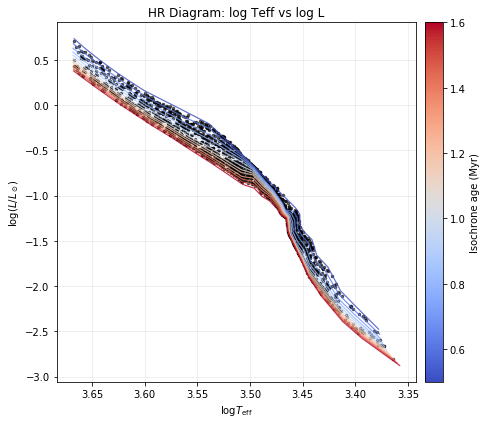

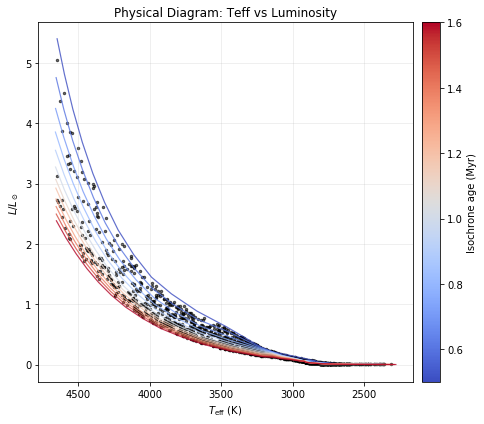

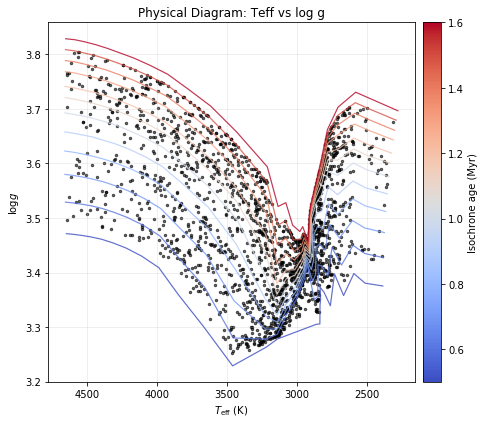

In [10]:
plot_hrd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    xcol='logTeff',
    ycol='logL',
    xlabel=r'$\log T_{\mathrm{eff}}$',
    ylabel=r'$\log(L/L_\odot)$',
    invert_x=True,
    title='HR Diagram: log Teff vs log L',
    x_mode='logTeff',
    y_mode='logL'
)

plot_hrd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    xcol='teff',
    ycol='lum_lsun',
    xlabel=r'$T_{\mathrm{eff}}$ (K)',
    ylabel=r'$L/L_\odot$',
    invert_x=True,
    title='Physical Diagram: Teff vs Luminosity',
    x_mode='teff',
    y_mode='lum'
)

plot_hrd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    xcol='teff',
    ycol='logg',
    xlabel=r'$T_{\mathrm{eff}}$ (K)',
    ylabel=r'$\log g$',
    invert_x=True,
    title='Physical Diagram: Teff vs log g',
    x_mode='teff',
    y_mode='logg'
)

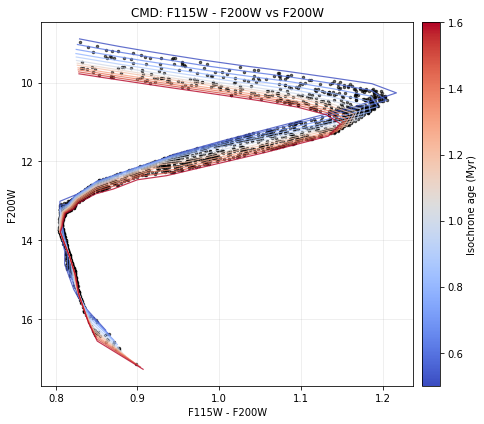

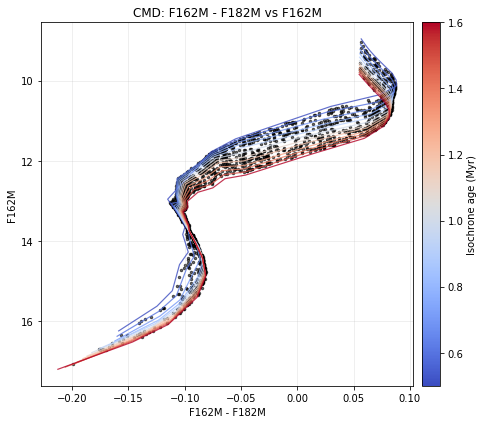

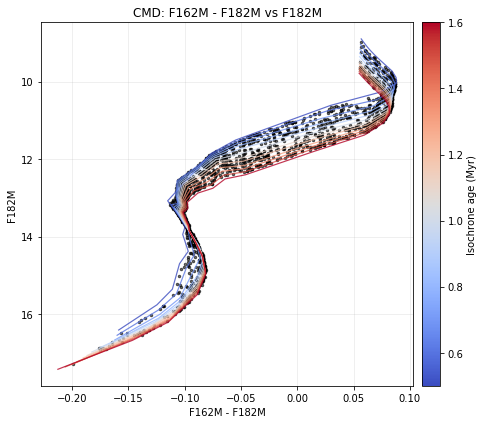

In [11]:
plot_cmd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    filt_a='F115W', filt_b='F200W', mag_filt='F200W',
    title='CMD: F115W - F200W vs F200W'
)

plot_cmd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    filt_a='F162M', filt_b='F182M', mag_filt='F162M',
    title='CMD: F162M - F182M vs F162M'
)

plot_cmd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    filt_a='F162M', filt_b='F182M', mag_filt='F182M',
    title='CMD: F162M - F182M vs F182M'
)

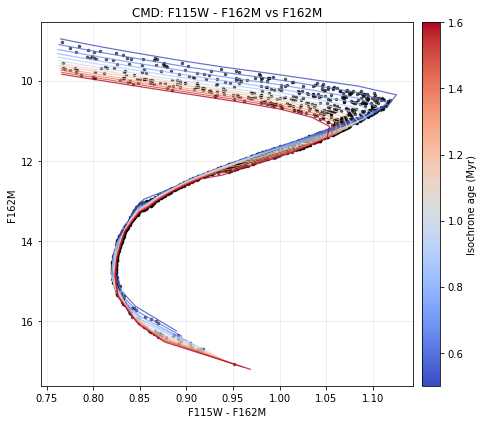

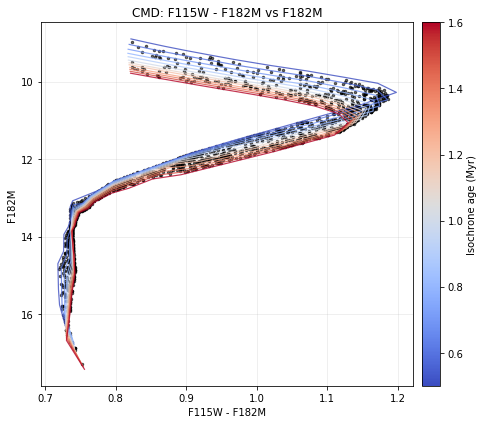

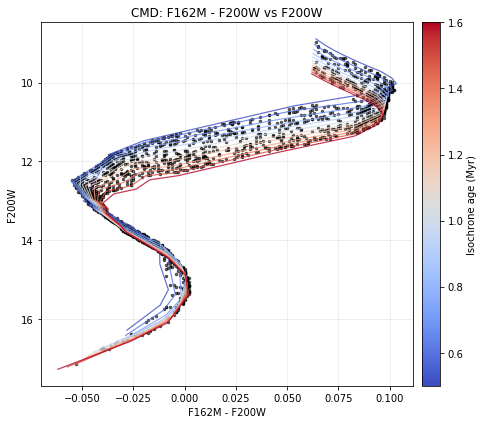

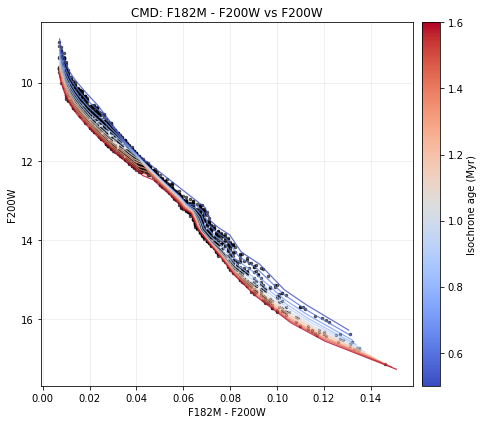

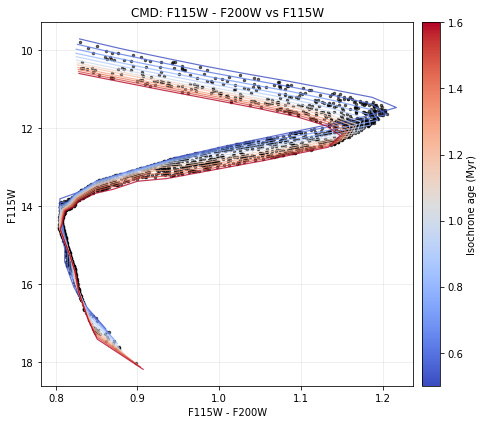

In [12]:
plot_cmd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    filt_a='F115W', filt_b='F162M', mag_filt='F162M',
    title='CMD: F115W - F162M vs F162M'
)

plot_cmd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    filt_a='F115W', filt_b='F182M', mag_filt='F182M',
    title='CMD: F115W - F182M vs F182M'
)

plot_cmd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    filt_a='F162M', filt_b='F200W', mag_filt='F200W',
    title='CMD: F162M - F200W vs F200W'
)

plot_cmd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    filt_a='F182M', filt_b='F200W', mag_filt='F200W',
    title='CMD: F182M - F200W vs F200W'
)

plot_cmd(
    master_df,
    iso_grid,
    level_age_arr_yr,
    filt_a='F115W', filt_b='F200W', mag_filt='F115W',
    title='CMD: F115W - F200W vs F115W'
)

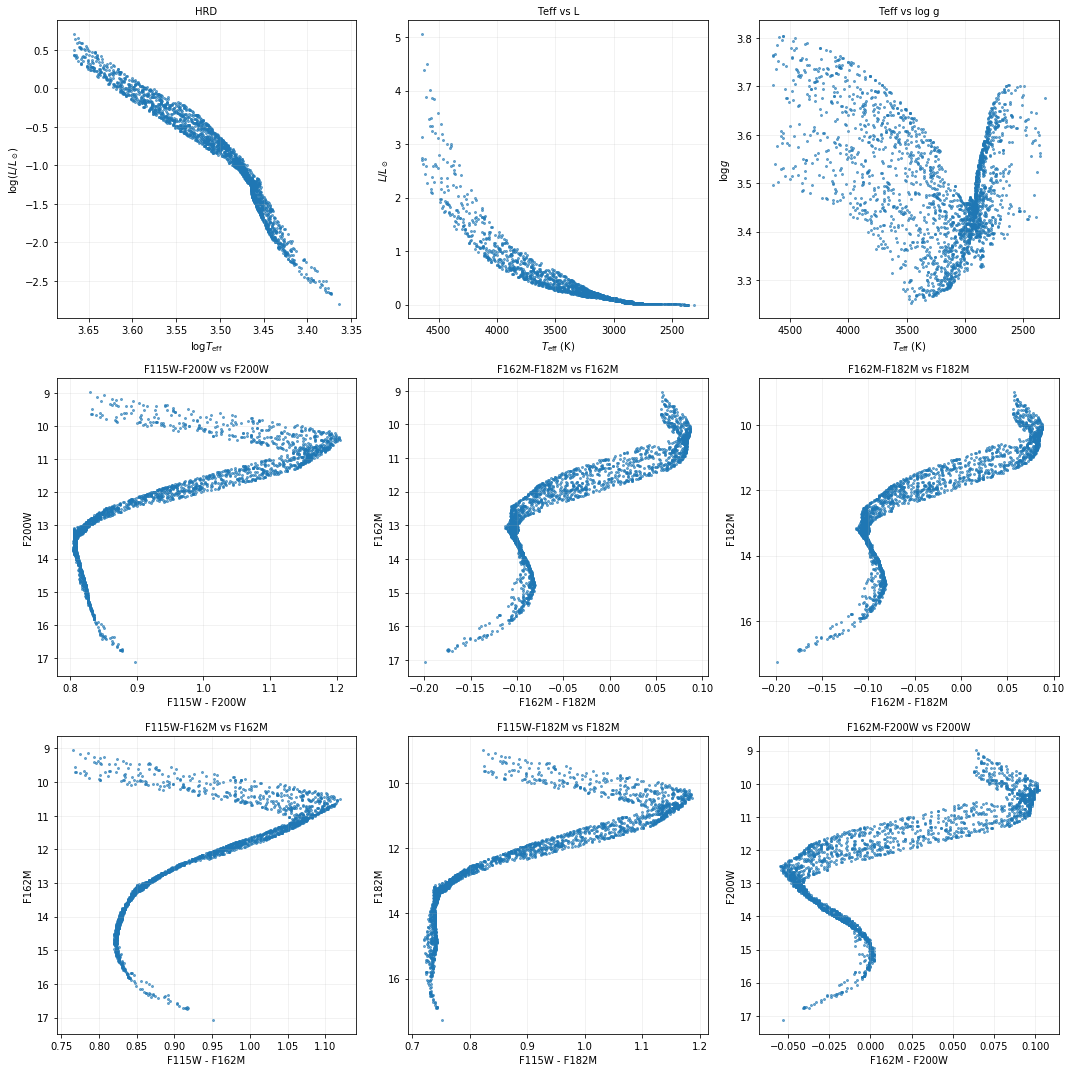

In [13]:
plot_specs = [
    ('logTeff', 'logL', None, None, r'$\log T_{\mathrm{eff}}$', r'$\log(L/L_\odot)$', True, False, 'HRD'),
    ('teff', 'lum_lsun', None, None, r'$T_{\mathrm{eff}}$ (K)', r'$L/L_\odot$', True, False, 'Teff vs L'),
    ('teff', 'logg', None, None, r'$T_{\mathrm{eff}}$ (K)', r'$\log g$', True, False, 'Teff vs log g'),
    ('F115W', 'F200W', 'F200W', 'cmd', 'F115W - F200W', 'F200W', False, True, 'F115W-F200W vs F200W'),
    ('F162M', 'F182M', 'F162M', 'cmd', 'F162M - F182M', 'F162M', False, True, 'F162M-F182M vs F162M'),
    ('F162M', 'F182M', 'F182M', 'cmd', 'F162M - F182M', 'F182M', False, True, 'F162M-F182M vs F182M'),
    ('F115W', 'F162M', 'F162M', 'cmd', 'F115W - F162M', 'F162M', False, True, 'F115W-F162M vs F162M'),
    ('F115W', 'F182M', 'F182M', 'cmd', 'F115W - F182M', 'F182M', False, True, 'F115W-F182M vs F182M'),
    ('F162M', 'F200W', 'F200W', 'cmd', 'F162M - F200W', 'F200W', False, True, 'F162M-F200W vs F200W'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, spec in zip(axes.flat, plot_specs):
    a, b, c, kind, xlabel, ylabel, invert_x, invert_y, title = spec

    if kind == 'cmd':
        x = master_df[FILTER_MAP[a]] - master_df[FILTER_MAP[b]]
        y = master_df[FILTER_MAP[c]]
    else:
        x = master_df[a]
        y = master_df[b]

    ax.scatter(x, y, s=4, alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.2)

    if invert_x:
        ax.invert_xaxis()
    if invert_y:
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [20]:
OUTDIR = 'science-images'

os.makedirs(OUTDIR, exist_ok=True)

# consistent styling for paper figures

CMD_POINT_SIZE = 3

CMD_ALPHA = 0.65

GRID_ALPHA = 0.15

plt.rcParams.update({

    'font.size': 11,

    'axes.titlesize': 12,

    'axes.labelsize': 11,

    'xtick.labelsize': 10,

    'ytick.labelsize': 10,

})

def get_cmd_xy(df, filt_a, filt_b, mag_filt):
    x = df[FILTER_MAP[filt_a]] - df[FILTER_MAP[filt_b]]
    y = df[FILTER_MAP[mag_filt]]
    return x.values, y.values

def set_cmd_panel(ax, x, y, xlabel, ylabel, title, xlim=None, ylim=None):
    ax.scatter(x, y, s=CMD_POINT_SIZE, alpha=CMD_ALPHA, color='k', linewidths=0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=GRID_ALPHA)
    ax.invert_yaxis()
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

def set_hrd_panel(ax, x, y, xlabel, ylabel, title, invert_x=True, xlim=None, ylim=None):
    ax.scatter(x, y, s=CMD_POINT_SIZE, alpha=CMD_ALPHA, color='k', linewidths=0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=GRID_ALPHA)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if invert_x:
        ax.invert_xaxis()

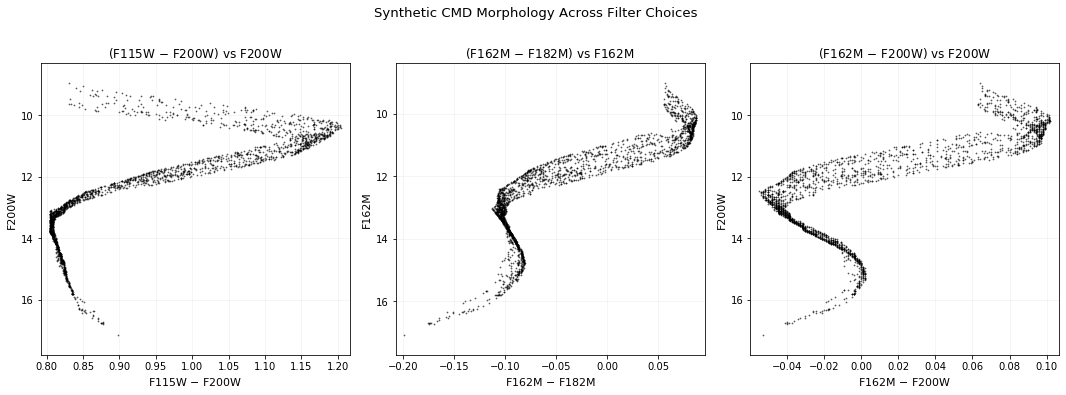

Saved: science-images/fig_cmd_multifilter_comparison.png


In [21]:
# choose the three CMDs we want
cmd_specs = [
    ('F115W', 'F200W', 'F200W', r'F115W $-$ F200W', 'F200W', r'(F115W $-$ F200W) vs F200W'),
    ('F162M', 'F182M', 'F162M', r'F162M $-$ F182M', 'F162M', r'(F162M $-$ F182M) vs F162M'),
    ('F162M', 'F200W', 'F200W', r'F162M $-$ F200W', 'F200W', r'(F162M $-$ F200W) vs F200W'),
]

# compute common limits separately for each panel type
cmd_data = [get_cmd_xy(master_df, a, b, m) for a, b, m, _, _, _ in cmd_specs]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.3))

for ax, spec, (x, y) in zip(axes, cmd_specs, cmd_data):
    filt_a, filt_b, mag_filt, xlabel, ylabel, title = spec

    # use per-panel limits so each morphology is visible cleanly
    xpad = 0.03 * (x.max() - x.min() if x.max() > x.min() else 1.0)
    ypad = 0.08 * (y.max() - y.min() if y.max() > y.min() else 1.0)

    xlim = (x.min() - xpad, x.max() + xpad)
    ylim = (y.max() + ypad, y.min() - ypad)

    set_cmd_panel(ax, x, y, xlabel, ylabel, title, xlim=xlim, ylim=ylim)

fig.suptitle('Synthetic CMD Morphology Across Filter Choices', y=1.03)
fig.tight_layout(rect=[0, 0, 1, 0.96])

outfile = os.path.join(OUTDIR, 'fig_cmd_multifilter_comparison.png')
fig.savefig(outfile, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {outfile}')

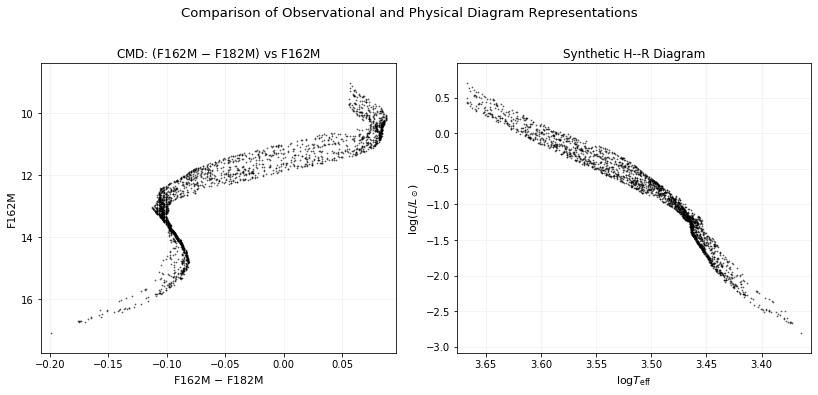

Saved: science-images/fig_cmd_vs_hrd_comparison.png


In [22]:
# CMD panel data
cmd_x, cmd_y = get_cmd_xy(master_df, 'F162M', 'F182M', 'F162M')

# HRD panel data
hrd_x = master_df['logTeff'].values
hrd_y = master_df['logL'].values

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.3))

# CMD
cmd_xpad = 0.03 * (cmd_x.max() - cmd_x.min() if cmd_x.max() > cmd_x.min() else 1.0)
cmd_ypad = 0.08 * (cmd_y.max() - cmd_y.min() if cmd_y.max() > cmd_y.min() else 1.0)
cmd_xlim = (cmd_x.min() - cmd_xpad, cmd_x.max() + cmd_xpad)
cmd_ylim = (cmd_y.max() + cmd_ypad, cmd_y.min() - cmd_ypad)

set_cmd_panel(
    axes[0],
    cmd_x,
    cmd_y,
    r'F162M $-$ F182M',
    'F162M',
    r'CMD: (F162M $-$ F182M) vs F162M',
    xlim=cmd_xlim,
    ylim=cmd_ylim
)

# HRD
hrd_xpad = 0.03 * (hrd_x.max() - hrd_x.min() if hrd_x.max() > hrd_x.min() else 1.0)
hrd_ypad = 0.08 * (hrd_y.max() - hrd_y.min() if hrd_y.max() > hrd_y.min() else 1.0)
hrd_xlim = (hrd_x.min() - hrd_xpad, hrd_x.max() + hrd_xpad)
hrd_ylim = (hrd_y.min() - hrd_ypad, hrd_y.max() + hrd_ypad)

set_hrd_panel(
    axes[1],
    hrd_x,
    hrd_y,
    r'$\log T_{\mathrm{eff}}$',
    r'$\log(L/L_\odot)$',
    'Synthetic H--R Diagram',
    invert_x=True,
    xlim=hrd_xlim,
    ylim=hrd_ylim
)

fig.suptitle('Comparison of Observational and Physical Diagram Representations', y=1.03)
fig.tight_layout(rect=[0, 0, 1, 0.96])

outfile = os.path.join(OUTDIR, 'fig_cmd_vs_hrd_comparison.png')
fig.savefig(outfile, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {outfile}')